<a href="https://colab.research.google.com/github/FernandoCasco/PARCIAL4_PEREZ-FERNANDO-2503592022/blob/main/Notebook/Asociacion_ClaveB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [5]:
url = "https://raw.githubusercontent.com/FernandoCasco/PARCIAL4_PEREZ-FERNANDO-2503592022/refs/heads/main/Data/clave_B_asociacion.csv"

df = pd.read_csv(url)

In [6]:
df.head()

,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,B-T0001,B-C0076,2026-01-03,Salud,Alcohol,1,Tienda
1,B-T0001,B-C0076,2026-01-03,Medicamentos,Antigripal,1,Tienda
2,B-T0001,B-C0076,2026-01-03,Salud,Mascarilla,1,Tienda
3,B-T0001,B-C0076,2026-01-03,Bebes,Panal,1,Tienda
4,B-T0002,B-C0062,2026-03-26,Salud,Alcohol,1,App


In [7]:
print("\nValores nulos:")
print(df.isnull().sum())


Valores nulos:
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64


In [8]:
print("\nDuplicados:")
print(df.duplicated().sum())


Duplicados:
1


In [9]:
print("\nEstadística descriptiva:")
print(df.describe())


Estadística descriptiva:
         cantidad
count  603.000000
mean     1.509121
std      0.839929
min      1.000000
25%      1.000000
50%      1.000000
75%      2.000000
max      4.000000


In [10]:
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(603, 7)


In [11]:
print("\nInformación general:")
print(df.info())


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  603 non-null    object
 1   cliente_id      603 non-null    object
 2   fecha           603 non-null    object
 3   categoria       603 non-null    object
 4   item            603 non-null    object
 5   cantidad        603 non-null    int64 
 6   canal           602 non-null    object
dtypes: int64(1), object(6)
memory usage: 33.1+ KB
None


In [12]:
print("\nFRECUENCIA POR CATEGORÍA:")
print(df['categoria'].value_counts())

print("\nFRECUENCIA POR CANAL:")
print(df['canal'].value_counts())


FRECUENCIA POR CATEGORÍA:
categoria
Medicamentos    135
Bebes           126
Salud           124
Cuidado         110
Bienestar       108
Name: count, dtype: int64

FRECUENCIA POR CANAL:
canal
Tienda      306
App         161
Web         123
Telefono     12
Name: count, dtype: int64


In [13]:
from mlxtend.preprocessing import TransactionEncoder

transacciones = df.groupby('transaccion_id')['item'].apply(list).tolist()

te = TransactionEncoder()
te_array = te.fit(transacciones).transform(transacciones)

basket = pd.DataFrame(te_array, columns=te.columns_)

basket.head()

,Alcohol,Analgesico,Antiacido,Antigripal,Biberon,Bloqueador,Crema,Curitas,Electrolitos,Formula,Gel,Jabon,Mascarilla,Panal,Proteina,Shampoo,Te_relajante,Termometro,Toallitas,Vitaminas
0,True,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False
1,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True
3,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False


In [14]:
frecuencia_productos = basket.sum().sort_values(ascending=False)

print("\nFrecuencia de productos:")
print(frecuencia_productos)


Frecuencia de productos:
Vitaminas       50
Mascarilla      48
Antigripal      46
Panal           43
Proteina        42
Alcohol         40
Crema           39
Toallitas       38
Bloqueador      34
Antiacido       27
Te_relajante    26
Biberon         24
Gel             21
Curitas         21
Formula         21
Jabon           19
Electrolitos    19
Shampoo         17
Termometro      15
Analgesico      12
dtype: int64


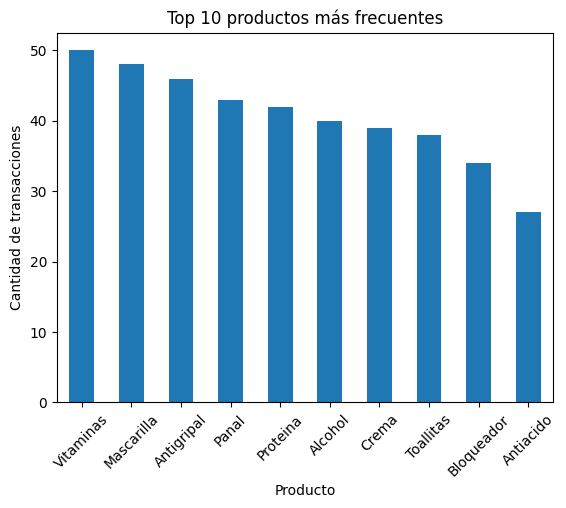

In [15]:
frecuencia_productos.head(10).plot(kind='bar')

plt.title("Top 10 productos más frecuentes")
plt.xlabel("Producto")
plt.ylabel("Cantidad de transacciones")

plt.xticks(rotation=45)

plt.show()

In [16]:
frecuentes = apriori(
    basket,
    min_support=0.05,
    use_colnames=True
)

# Ordenar por soporte
frecuentes = frecuentes.sort_values(
    by='support',
    ascending=False
)

print("\nItemsets frecuentes:")
print(frecuentes.head(10))


Itemsets frecuentes:
     support                  itemsets
19  0.294118               (Vitaminas)
12  0.282353              (Mascarilla)
3   0.270588              (Antigripal)
13  0.252941                   (Panal)
14  0.247059                (Proteina)
0   0.235294                 (Alcohol)
6   0.229412                   (Crema)
18  0.223529               (Toallitas)
5   0.200000              (Bloqueador)
25  0.170588  (Mascarilla, Antigripal)


In [17]:
reglas = association_rules(
    frecuentes,
    metric="lift",
    min_threshold=1
)

print("\nCANTIDAD DE REGLAS:")
print(reglas.shape)

print("\nCOLUMNAS DE REGLAS:")
print(reglas.columns)


CANTIDAD DE REGLAS:
(42, 14)

COLUMNAS DE REGLAS:
Index(['antecedents', 'consequents', 'antecedent support',
       'consequent support', 'support', 'confidence', 'lift',
       'representativity', 'leverage', 'conviction', 'zhangs_metric',
       'jaccard', 'certainty', 'kulczynski'],
      dtype='object')


In [18]:
reglas = reglas.sort_values(
    by=["lift", "confidence"],
    ascending=False
)

In [19]:
top10 = reglas[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].head(10)

print("\nTOP 10 REGLAS:")
print(top10)


TOP 10 REGLAS:
                 antecedents               consequents   support  confidence  \
8      (Mascarilla, Alcohol)              (Antigripal)  0.129412    0.916667   
13              (Antigripal)     (Mascarilla, Alcohol)  0.129412    0.478261   
9   (Mascarilla, Antigripal)                 (Alcohol)  0.129412    0.758621   
12                 (Alcohol)  (Mascarilla, Antigripal)  0.129412    0.550000   
10     (Alcohol, Antigripal)              (Mascarilla)  0.129412    0.846154   
11              (Mascarilla)     (Alcohol, Antigripal)  0.129412    0.458333   
4                  (Alcohol)              (Antigripal)  0.152941    0.650000   
5               (Antigripal)                 (Alcohol)  0.152941    0.565217   
3                 (Proteina)               (Vitaminas)  0.164706    0.666667   
2                (Vitaminas)                (Proteina)  0.164706    0.560000   

        lift  
8   3.387681  
13  3.387681  
9   3.224138  
12  3.224138  
10  2.996795  
11  2.996795 